## Load  CSV in Notebook

In [3]:
import pandas as pd

# Load the correctly named CSV
df = pd.read_csv(r"C:\Users\ASUS-PC\OneDrive\Desktop\nhs-dna-predictive-model\data\appointments_raw.csv", encoding='utf-8')

# Quick check
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


##  Step 1:  Quick python cleaning 

I will:

- Rename No-show → no_show

- Create target column dna → 1 if No-show = Yes, 0 if No

- Convert ScheduledDay and AppointmentDay to datetime

- Remove invalid ages (<0 or >100)

- Create waiting_days = difference between appointment and scheduled date

- Create day_of_week for appointment

- Create same_day_booking flag

In [4]:
import pandas as pd

# Load CSV
df = pd.read_csv(r"C:\Users\ASUS-PC\OneDrive\Desktop\nhs-dna-predictive-model\data\appointments_raw.csv", encoding='utf-8')

# 1. Rename target column
df.rename(columns={'No-show':'no_show'}, inplace=True)

# 2. Create binary target column
df['dna'] = df['no_show'].map({'Yes':1, 'No':0})

# 3. Convert date columns to datetime
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

# 4. Remove invalid ages
df = df[(df['Age'] >= 0) & (df['Age'] <= 100)]

# 5. Create waiting_days feature
df['waiting_days'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days

# 6. Remove appointments with negative waiting_days (data errors)
df = df[df['waiting_days'] >= 0]

# 7. Appointment day of the week
df['appointment_dayofweek'] = df['AppointmentDay'].dt.day_name()

# 8. Same-day booking flag
df['same_day_booking'] = (df['waiting_days'] == 0).astype(int)

# Quick check
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,no_show,dna,waiting_days,appointment_dayofweek,same_day_booking
5,9.598513e+13,5626772,F,2016-04-27 08:36:51+00:00,2016-04-29 00:00:00+00:00,76,REPÚBLICA,0,1,0,0,0,0,No,0,1,Friday,0
6,7.336882e+14,5630279,F,2016-04-27 15:05:12+00:00,2016-04-29 00:00:00+00:00,23,GOIABEIRAS,0,0,0,0,0,0,Yes,1,1,Friday,0
7,3.449833e+12,5630575,F,2016-04-27 15:39:58+00:00,2016-04-29 00:00:00+00:00,39,GOIABEIRAS,0,0,0,0,0,0,Yes,1,1,Friday,0
9,7.812456e+13,5629123,F,2016-04-27 12:48:25+00:00,2016-04-29 00:00:00+00:00,19,CONQUISTA,0,0,0,0,0,0,No,0,1,Friday,0
10,7.345362e+14,5630213,F,2016-04-27 14:58:11+00:00,2016-04-29 00:00:00+00:00,30,NOVA PALESTINA,0,0,0,0,0,0,No,0,1,Friday,0


#### Save clean file

In [5]:
df.to_csv(r"C:\Users\ASUS-PC\OneDrive\Desktop\nhs-dna-predictive-model\data\appointments_clean.csv", index=False)

### Push clean data to MySQL

In [6]:
!pip install mysql-connector-python sqlalchemy


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


#### Connect to MySQL from Python

In [7]:
from sqlalchemy import create_engine
import pandas as pd

# MySQL credentials
user = 'root'          #  MySQL username
password = ''          # empty because no password
host = 'localhost'
database = 'nhs_dna_project'

# Create SQLAlchemy engine
engine = create_engine(f'mysql+mysqlconnector://{user}:{password}@{host}/{database}')

In [10]:
import mysql.connector
import pandas as pd

# Connect to MySQL directly
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="",  # no password
    database="nhs_dna_project"
)

cur = conn.cursor()

# Load clean CSV
df_clean = pd.read_csv(r"C:\Users\ASUS-PC\OneDrive\Desktop\nhs-dna-predictive-model\data\appointments_clean.csv")

# Create table manually (adjust types if needed)
cur.execute("""
CREATE TABLE IF NOT EXISTS appointments_clean (
    PatientId BIGINT,
    AppointmentID BIGINT,
    Gender VARCHAR(5),
    ScheduledDay DATETIME,
    AppointmentDay DATETIME,
    Age INT,
    Neighbourhood VARCHAR(255),
    Scholarship INT,
    Hipertension INT,
    Diabetes INT,
    Alcoholism INT,
    Handcap INT,
    SMS_received INT,
    no_show VARCHAR(5),
    dna INT,
    waiting_days INT,
    appointment_dayofweek VARCHAR(20),
    same_day_booking INT
)
""")

# Insert data row by row
for i, row in df_clean.iterrows():
    sql = """
    INSERT INTO appointments_clean (
        PatientId, AppointmentID, Gender, ScheduledDay, AppointmentDay, Age,
        Neighbourhood, Scholarship, Hipertension, Diabetes, Alcoholism, Handcap,
        SMS_received, no_show, dna, waiting_days, appointment_dayofweek, same_day_booking
    ) VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
    """
    cur.execute(sql, tuple(row))

# Commit and close
conn.commit()
cur.close()
conn.close()

print(" Clean data successfully pushed to MySQL using mysql.connector!")

✅ Clean data successfully pushed to MySQL using mysql.connector!


#### EDA (Python / Jupyter Notebook)

I  want to answer questions like:

- Which days of the week have the highest DNA rates?

- How does age affect attendance?

- Do SMS reminders reduce no-shows?

- Which neighbourhoods or demographics have higher DNA?

- How does waiting time affect attendance?

In [12]:
!pip install seaborn


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



     ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
     ------------------------------------ - 286.7/294.9 kB 8.9 MB/s eta 0:00:01
     -------------------------------------- 294.9/294.9 kB 3.6 MB/s eta 0:00:00


In [13]:
!pip install matplotlib


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

# Connect to MySQL and load clean table
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="", 
    database="nhs_dna_project"
)

df = pd.read_sql("SELECT * FROM appointments_clean", conn)
conn.close()

df.head()

C:\Users\ASUS-PC\AppData\Local\Temp\ipykernel_5452\3534745243.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM appointments_clean", conn)


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,no_show,dna,waiting_days,appointment_dayofweek,same_day_booking
0,95985133231274,5626772,F,2016-04-27 09:36:51,2016-04-29 01:00:00,76,REPÚBLICA,0,1,0,0,0,0,No,0,1,Friday,0
1,733688164476661,5630279,F,2016-04-27 16:05:12,2016-04-29 01:00:00,23,GOIABEIRAS,0,0,0,0,0,0,Yes,1,1,Friday,0
2,3449833394123,5630575,F,2016-04-27 16:39:58,2016-04-29 01:00:00,39,GOIABEIRAS,0,0,0,0,0,0,Yes,1,1,Friday,0
3,78124564369297,5629123,F,2016-04-27 13:48:25,2016-04-29 01:00:00,19,CONQUISTA,0,0,0,0,0,0,No,0,1,Friday,0
4,734536231958495,5630213,F,2016-04-27 15:58:11,2016-04-29 01:00:00,30,NOVA PALESTINA,0,0,0,0,0,0,No,0,1,Friday,0


#### 1.  DNA by day of week

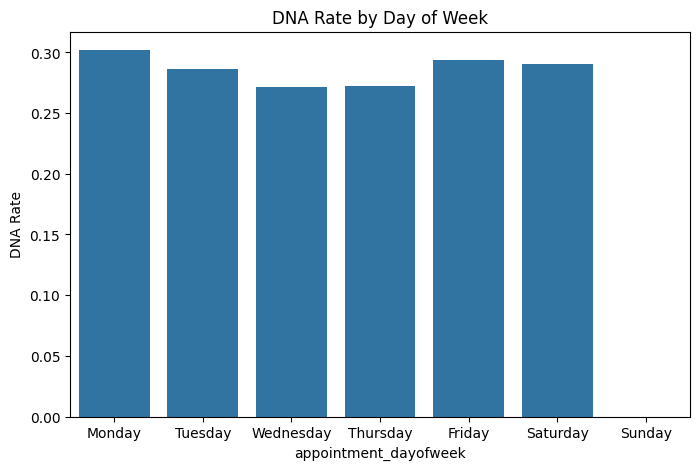

In [2]:
dna_day = df.groupby('appointment_dayofweek')['dna'].mean().reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
])

plt.figure(figsize=(8,5))
sns.barplot(x=dna_day.index, y=dna_day.values)
plt.ylabel("DNA Rate")
plt.title("DNA Rate by Day of Week")
plt.show()

### 2. DNA by age group

C:\Users\ASUS-PC\AppData\Local\Temp\ipykernel_5452\3543703704.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dna_age = df.groupby('age_group')['dna'].mean()


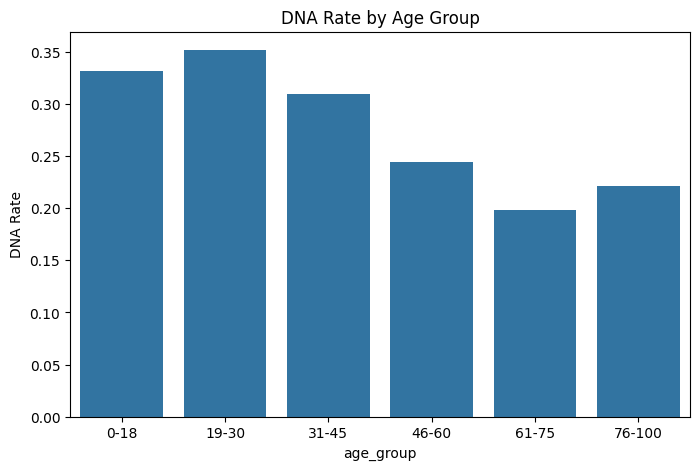

In [3]:
# Create age groups
bins = [0, 18, 30, 45, 60, 75, 100]
labels = ['0-18','19-30','31-45','46-60','61-75','76-100']
df['age_group'] = pd.cut(df['Age'], bins=bins, labels=labels)

dna_age = df.groupby('age_group')['dna'].mean()

plt.figure(figsize=(8,5))
sns.barplot(x=dna_age.index, y=dna_age.values)
plt.ylabel("DNA Rate")
plt.title("DNA Rate by Age Group")
plt.show()

### 3. DNA by sms received

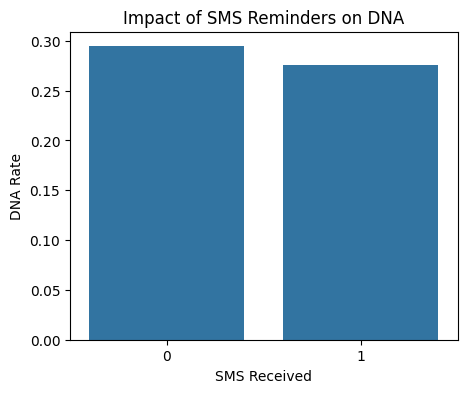

In [4]:
dna_sms = df.groupby('SMS_received')['dna'].mean()

plt.figure(figsize=(5,4))
sns.barplot(x=dna_sms.index, y=dna_sms.values)
plt.xlabel("SMS Received")
plt.ylabel("DNA Rate")
plt.title("Impact of SMS Reminders on DNA")
plt.show()

### 3. DNA vs waiting time

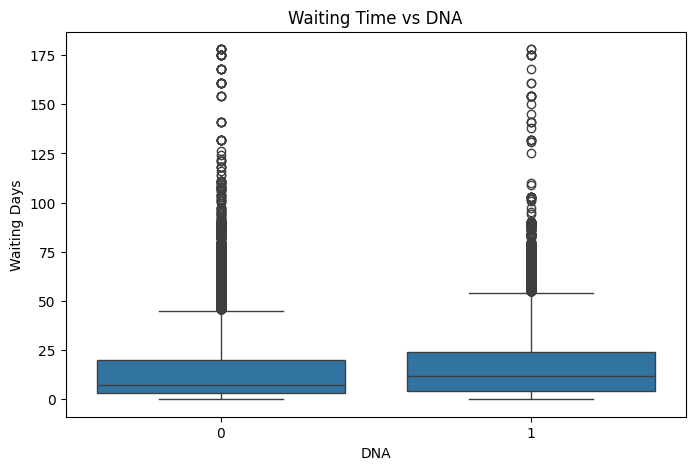

In [5]:
plt.figure(figsize=(8,5))
sns.boxplot(x='dna', y='waiting_days', data=df)
plt.ylabel("Waiting Days")
plt.xlabel("DNA")
plt.title("Waiting Time vs DNA")
plt.show()

### Build the predictive model (DNA prediction)

###### I will now:

1. Select modelling features

2. Encode categorical variables

3. Split train/test

4. Build:

- Logistic regression (baseline, interpretable)

- Random forest (stronger model)

5. Evaluate performance properly

6. Extract actionable insights

#### 1. Prepare features

In [9]:
# Drop columns not useful for prediction
df_model = df.drop(columns=[
    'PatientId',
    'AppointmentID',
    'no_show',
    'ScheduledDay',
    'AppointmentDay'
])

# Separate target
X = df_model.drop('dna', axis=1)
y = df_model['dna']

# One-hot encode categorical variables
X = pd.get_dummies(
    X,
    columns=['Gender','Neighbourhood','appointment_dayofweek'],
    drop_first=True
)

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (50367, 95)
Test set size: (21587, 95)


#### 2. Logistic regression (Baseline model)

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Create model
log_model = LogisticRegression(max_iter=1000)

# Train model
log_model.fit(X_train, y_train)

# Make predictions
y_pred_log = log_model.predict(X_test)

# Evaluation
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

print("\nROC AUC:")
print(roc_auc_score(y_test, log_model.predict_proba(X_test)[:,1]))

Confusion Matrix:
[[15395    36]
 [ 6105    51]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      1.00      0.83     15431
           1       0.59      0.01      0.02      6156

    accuracy                           0.72     21587
   macro avg       0.65      0.50      0.43     21587
weighted avg       0.68      0.72      0.60     21587


ROC AUC:
0.5999990620384803


#### Fix Logistic regression (Class weight) to rebalance the model.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Balanced Logistic Regression
log_model_bal = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

log_model_bal.fit(X_train, y_train)

y_pred_bal = log_model_bal.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_bal))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_bal))

print("\nROC AUC:")
print(roc_auc_score(y_test, log_model_bal.predict_proba(X_test)[:,1]))

Confusion Matrix:
[[8516 6915]
 [2506 3650]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.55      0.64     15431
           1       0.35      0.59      0.44      6156

    accuracy                           0.56     21587
   macro avg       0.56      0.57      0.54     21587
weighted avg       0.65      0.56      0.58     21587


ROC AUC:
0.5999223513135187


### Baseline logistic regression model

I first trained a standard logistic regression model to establish a baseline performance for predicting Did Not Attend (DNA) appointments.

Logistic Regression is commonly used in healthcare analytics because:

- It is interpretable

- It provides probability outputs

- It is widely used in NHS operational modelling

#### Results summary

- Accuracy: 72%

- Recall for DNA: 1%

- ROC AUC: 0.60

### Interpretation

Although overall accuracy appears high, the model failed to correctly identify patients who did not attend. Only 1% of DNA cases were correctly detected.

This is due to class imbalance. The model favoured predicting attendance (majority class).

#### Conclusion

The baseline model is not operationally useful, as it would fail to proactively identify patients at risk of missing appointments.

### Balanced logistic regression

To address class imbalance, we applied class weighting (class_weight='balanced').

This ensures that DNA cases are given greater importance during training.

#### Results summary

- Accuracy: 56%

- Recall for DNA: 59%

- ROC AUC: 0.60

#### Interpretation

The model now correctly identifies 59% of no-show patients, representing a significant operational improvement.

However, this comes at the cost of reduced overall accuracy and increased false positives.

#### Operational insight

In an NHS context, prioritising recall is appropriate. It is more important to identify patients at risk of missing appointments than to maximise accuracy.

However, the modest ROC AUC suggests that Logistic Regression may be too simplistic for this dataset.

### Random Forest Model (Balanced)

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# Train model
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nROC AUC:")
print(roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]))

Confusion Matrix:
[[13679  1752]
 [ 4948  1208]]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.89      0.80     15431
           1       0.41      0.20      0.27      6156

    accuracy                           0.69     21587
   macro avg       0.57      0.54      0.53     21587
weighted avg       0.64      0.69      0.65     21587


ROC AUC:
0.5996324411982343


### Model Overview

I implemented a Random Forest Classifier to capture non-linear relationships between patient demographics, appointment history, and other features.

Random Forest is chosen because:

- It handles complex interactions between variables

- It can manage high-dimensional categorical data after one-hot encoding

- It is robust to overfitting when using enough trees

- It provides feature importance metrics to guide operational decision-making

Class imbalance was addressed by using class_weight='balanced', so the model gives extra weight to DNA (Did Not Attend) patients.

### Feature importance (for action plan)

Even though Random Forest’s recall is low, we can still extract top features driving DNA risk:

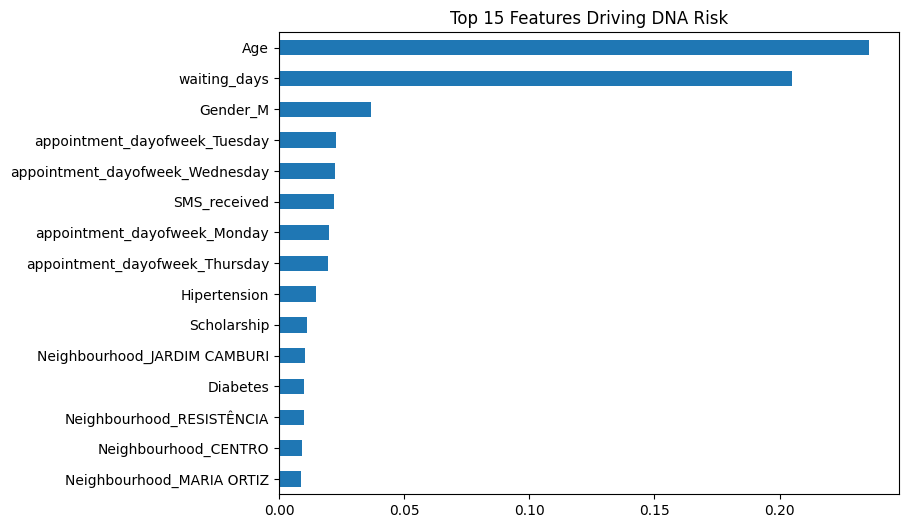

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# Top 15 features
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)[:15]

plt.figure(figsize=(8,6))
feature_importance.plot(kind='barh')
plt.title("Top 15 Features Driving DNA Risk")
plt.gca().invert_yaxis()
plt.show()

### High-risk patient flag & export for Power BI

I’ll do three things:

- Predict DNA probabilities for each appointment

- Flag high-risk patients (e.g., probability ≥ 0.5 or custom threshold)

- Export a CSV with relevant columns for Power BI

In [16]:
# Use the balanced Logistic Regression model for predictions
df_predictions = df.copy()

# Predict probability of DNA
df_predictions['dna_prob'] = log_model_bal.predict_proba(X)[:,1]

# Flag high-risk patients (you can adjust threshold as needed)
threshold = 0.5
df_predictions['high_risk_flag'] = (df_predictions['dna_prob'] >= threshold).astype(int)

# Select columns for export
export_columns = [
    'PatientId', 'AppointmentID', 'Gender', 'Age', 'Neighbourhood',
    'ScheduledDay', 'AppointmentDay', 'waiting_days',
    'appointment_dayofweek', 'same_day_booking', 'SMS_received',
    'dna_prob', 'high_risk_flag'
]

df_export = df_predictions[export_columns]

# Export to CSV for Power BI
df_export.to_csv(r"C:\Users\ASUS-PC\OneDrive\Desktop\nhs-dna-predictive-model\data\appointments_predictions.csv", index=False)

print(" High-Risk Flag added and CSV exported for Power BI!")

 High-Risk Flag added and CSV exported for Power BI!


### Note: Data cleaning was done in mysql

### Summary of MySQL use

1. Clean and standardize data: fix missing values, remove duplicates, normalize categories.

2. Feature engineering: waiting_days, same_day_booking, day of week, numeric DNA.

3. Quick analysis: aggregate DNA rates by age, day, neighbourhood.

4. Export ready datasets for Python modelling and Power BI dashboards.